# Pasos 8, 9 y 10 — Métricas, Curvas y Optimización del Modelo
**Confusion Matrix | ROC | Feature Importance | Comparativa final**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize
from tensorflow import keras

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

BASE_DIR  = os.path.abspath('..')
PROCESSED = os.path.join(BASE_DIR, 'dataset', 'processed')
MODELS    = os.path.join(BASE_DIR, 'models')
FIGURES   = os.path.join(BASE_DIR, 'docs', 'figures')

X_test  = np.load(os.path.join(PROCESSED, 'X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED, 'y_test.npy'))
le      = joblib.load(os.path.join(MODELS, 'label_encoder.pkl'))
rf      = joblib.load(os.path.join(MODELS, 'random_forest.pkl'))
rna     = keras.models.load_model(os.path.join(MODELS, 'rna_mejor.keras'))

y_pred_rf    = rf.predict(X_test)
y_pred_rna   = np.argmax(rna.predict(X_test, verbose=0), axis=1)
y_proba_rf   = rf.predict_proba(X_test)
y_proba_rna  = rna.predict(X_test, verbose=0)

CLASES = list(le.classes_)
PALETA = {'Optima': '#2ECC71', 'Alerta': '#F39C12', 'Contaminada': '#E74C3C'}
print(f'Modelos cargados. Test: {X_test.shape[0]:,} muestras')

Modelos cargados. Test: 909 muestras


## 8.1 — Reportes de clasificación completos

In [2]:
for nombre, y_pred in [('RANDOM FOREST', y_pred_rf), ('RED NEURONAL (RNA)', y_pred_rna)]:
    print(f'\n{"="*55}')
    print(f' MODELO: {nombre}')
    print(f'{"="*55}')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}  '
          f'({accuracy_score(y_test, y_pred)*100:.1f}%)')
    print('\nReporte de clasificación:')
    print(classification_report(y_test, y_pred, target_names=CLASES))


 MODELO: RANDOM FOREST
Accuracy: 0.9978  (99.8%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Alerta       0.98      1.00      0.99        97
 Contaminada       1.00      1.00      1.00       751
      Optima       1.00      0.97      0.98        61

    accuracy                           1.00       909
   macro avg       0.99      0.99      0.99       909
weighted avg       1.00      1.00      1.00       909


 MODELO: RED NEURONAL (RNA)
Accuracy: 0.9989  (99.9%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Alerta       0.99      1.00      0.99        97
 Contaminada       1.00      1.00      1.00       751
      Optima       1.00      1.00      1.00        61

    accuracy                           1.00       909
   macro avg       1.00      1.00      1.00       909
weighted avg       1.00      1.00      1.00       909



## 8.2 — Matrices de confusión

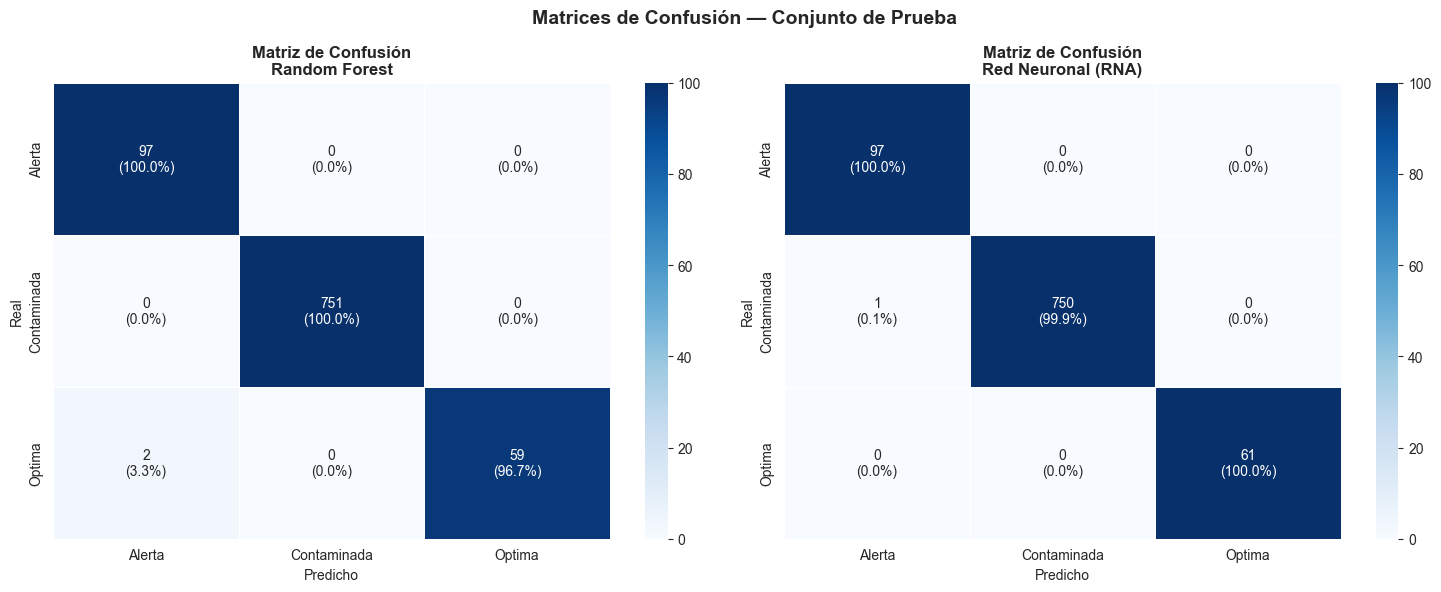

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (nombre, y_pred) in zip(axes, [('Random Forest', y_pred_rf),
                                         ('Red Neuronal (RNA)', y_pred_rna)]):
    cm = confusion_matrix(y_test, y_pred)
    # Normalizar para mostrar porcentajes
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    annot = np.array([[f'{v:.0f}\n({p:.1f}%)'
                       for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=CLASES, yticklabels=CLASES, ax=ax,
                linewidths=0.5, vmin=0, vmax=100)
    ax.set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '06_matrices_confusion.png'), dpi=150)
plt.show()

## 9.1 — Curvas ROC multiclase (One-vs-Rest)

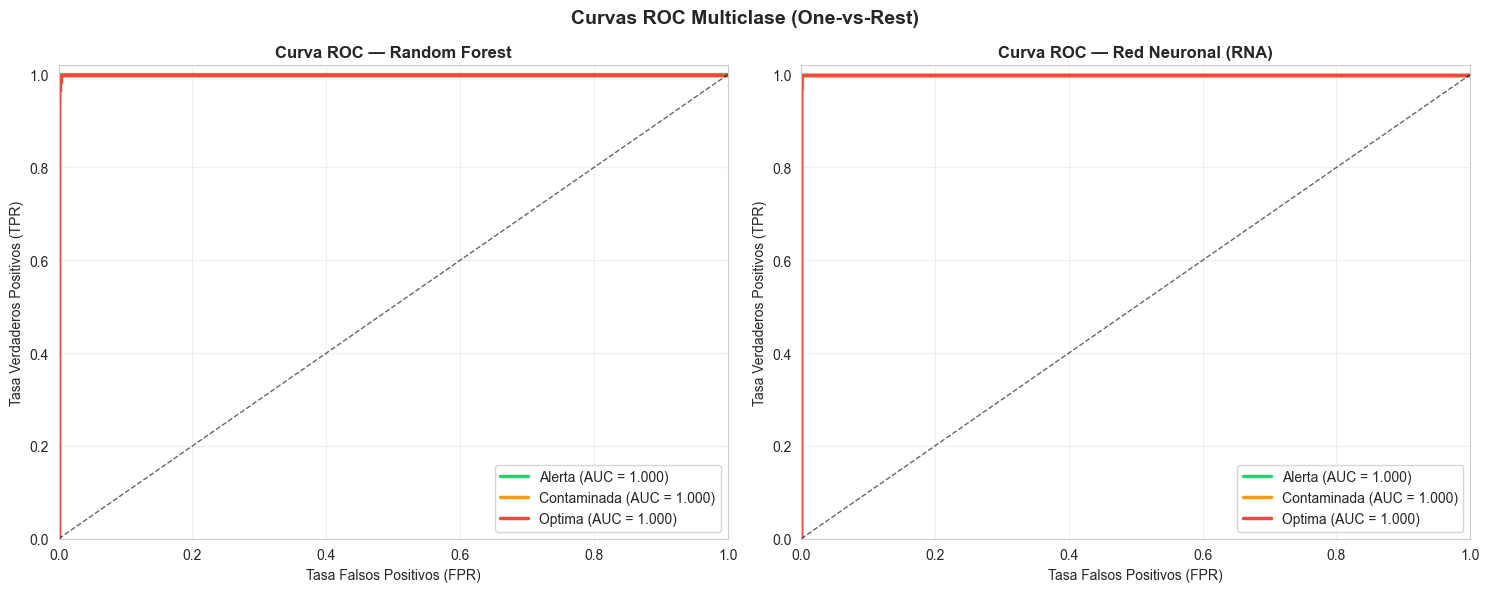

AUC-ROC promedio — RF: 0.9999 | RNA: 1.0000


In [4]:
def plot_roc(ax, nombre, y_true, y_proba, le):
    y_bin    = label_binarize(y_true, classes=range(len(le.classes_)))
    colores  = ['#2ECC71', '#F39C12', '#E74C3C']
    auc_list = []

    for i, (clase, color) in enumerate(zip(le.classes_, colores)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        auc_list.append(roc_auc)
        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'{clase} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('Tasa Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {nombre}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    return np.mean(auc_list)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
auc_rf  = plot_roc(axes[0], 'Random Forest',     y_test, y_proba_rf,  le)
auc_rna = plot_roc(axes[1], 'Red Neuronal (RNA)', y_test, y_proba_rna, le)

plt.suptitle('Curvas ROC Multiclase (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '06_curvas_roc.png'), dpi=150)
plt.show()
print(f'AUC-ROC promedio — RF: {auc_rf:.4f} | RNA: {auc_rna:.4f}')

## 9.2 — Importancia de variables (Random Forest)

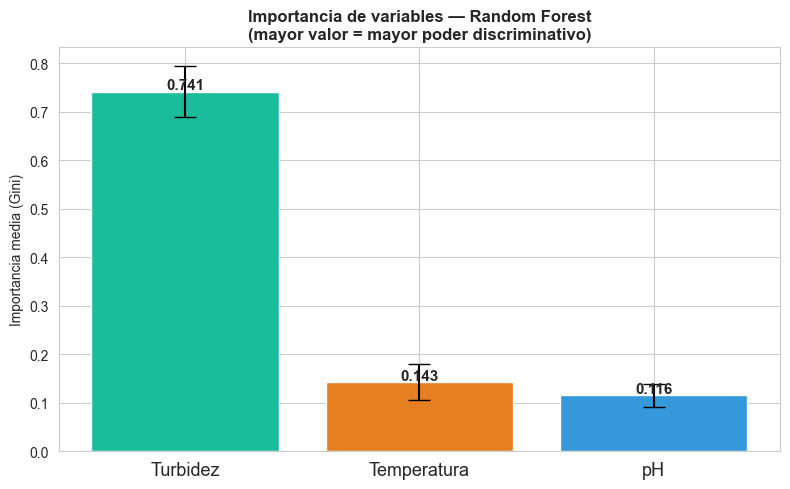

In [5]:
PARAMS       = ['pH', 'Turbidez', 'Temperatura']
importancias = rf.feature_importances_
std_imp      = np.std([t.feature_importances_ for t in rf.estimators_], axis=0)

idx = np.argsort(importancias)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#3498DB', '#1ABC9C', '#E67E22']
bars = ax.bar(range(len(PARAMS)),
              importancias[idx],
              yerr=std_imp[idx],
              color=[colores[i] for i in idx],
              capsize=8, edgecolor='white')
ax.set_xticks(range(len(PARAMS)))
ax.set_xticklabels([PARAMS[i] for i in idx], fontsize=13)
ax.set_ylabel('Importancia media (Gini)')
ax.set_title('Importancia de variables — Random Forest\n'
             '(mayor valor = mayor poder discriminativo)',
             fontweight='bold')
for bar, val in zip(bars, importancias[idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '06_feature_importance.png'), dpi=150)
plt.show()

## 10 — Comparativa final y selección del mejor modelo

In [6]:
from sklearn.metrics import precision_score, recall_score

resultados = []
for nombre, y_pred, y_proba in [
    ('Random Forest',     y_pred_rf,  y_proba_rf),
    ('Red Neuronal (RNA)', y_pred_rna, y_proba_rna)
]:
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'F1-score':  round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted'), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'), 4)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo')
print('=== COMPARATIVA FINAL DE MODELOS ===')
print(tabla.to_string())

mejor = tabla['F1-score'].idxmax()
print(f'\n→ Modelo seleccionado para producción: {mejor}')

=== COMPARATIVA FINAL DE MODELOS ===
                    Accuracy  F1-score  Precision  Recall  AUC-ROC
Modelo                                                            
Random Forest         0.9978    0.9978     0.9978  0.9978      1.0
Red Neuronal (RNA)    0.9989    0.9989     0.9989  0.9989      1.0

→ Modelo seleccionado para producción: Red Neuronal (RNA)


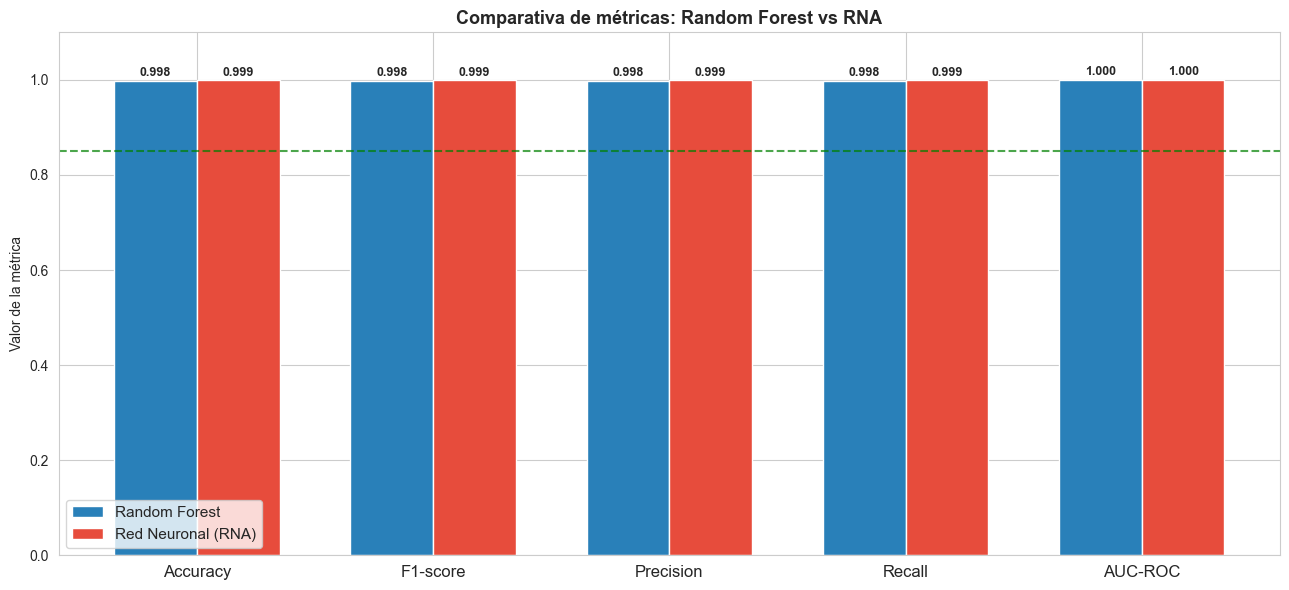

In [7]:
# Gráfico comparativo de métricas
metricas = ['Accuracy', 'F1-score', 'Precision', 'Recall', 'AUC-ROC']
x        = np.arange(len(metricas))
ancho    = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - ancho/2, tabla.loc['Random Forest', metricas],     ancho,
            label='Random Forest',     color='#2980B9', edgecolor='white')
b2 = ax.bar(x + ancho/2, tabla.loc['Red Neuronal (RNA)', metricas], ancho,
            label='Red Neuronal (RNA)', color='#E74C3C', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim([0, 1.1])
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparativa de métricas: Random Forest vs RNA', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(0.85, color='green', linestyle='--', alpha=0.7, label='Meta 85%')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '06_comparativa_modelos.png'), dpi=150)
plt.show()

In [8]:
# Exportar tabla de resultados
tabla.to_csv(os.path.join(BASE_DIR, 'models', 'resultados_evaluacion.csv'))
print('Resultados guardados en models/resultados_evaluacion.csv')
print('\nListo para integrar en el backend FastAPI.')

Resultados guardados en models/resultados_evaluacion.csv

Listo para integrar en el backend FastAPI.
